In [1]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.4f}'.format)



sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

imports ok


In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Load data
data = pd.read_csv('/content/gdrive/MyDrive/Machine Learning_Datasets for design/DATASET_triangles.csv', delimiter= " ")
pd.set_option('display.max_columns', None)

print(data)

        angX    angY    lenX    lenY  hypotenuse  perimeter      area  \
0    59.9838 30.0162 49.1196 85.0221     98.1911   232.3328 2088.1265   
1    78.7978 11.2022 10.1378 51.1895     52.1837   113.5110  259.4752   
2    55.0935 34.9065 69.4121 99.4758    121.2991   290.1870 3452.4132   
3    55.2400 34.7600 52.6354 75.8453     92.3201   220.8008 1996.0739   
4    15.2189 74.7811 80.1719 21.8107     83.0858   185.0684  874.3024   
...      ...     ...     ...     ...         ...        ...       ...   
1995 44.3786 45.6214 62.0361 60.7049     86.7961   209.5371 1882.9474   
1996 52.4218 37.5782 49.7388 64.6380     81.5599   195.9367 1607.5078   
1997 28.6493 61.3507 91.5380 50.0104    104.3084   245.8569 2288.9264   
1998 50.2023 39.7977 26.0840 31.3096     40.7513    98.1448  408.3397   
1999 25.2947 64.7053 38.6995 18.2888     42.8034    99.7917  353.8834   

      circumscribedCir  origin_x  origin_y    xPt_x    xPt_y   yPt_x    yPt_y  
0              49.0955   32.0362   49.5434 

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   angX              2000 non-null   float64
 1   angY              2000 non-null   float64
 2   lenX              2000 non-null   float64
 3   lenY              2000 non-null   float64
 4   hypotenuse        2000 non-null   float64
 5   perimeter         2000 non-null   float64
 6   area              2000 non-null   float64
 7   circumscribedCir  2000 non-null   float64
 8   origin_x          2000 non-null   float64
 9   origin_y          2000 non-null   float64
 10  xPt_x             2000 non-null   float64
 11  xPt_y             2000 non-null   float64
 12  yPt_x             2000 non-null   float64
 13  yPt_y             2000 non-null   float64
dtypes: float64(14)
memory usage: 218.9 KB


array([[<Axes: title={'center': 'angX'}>]], dtype=object)

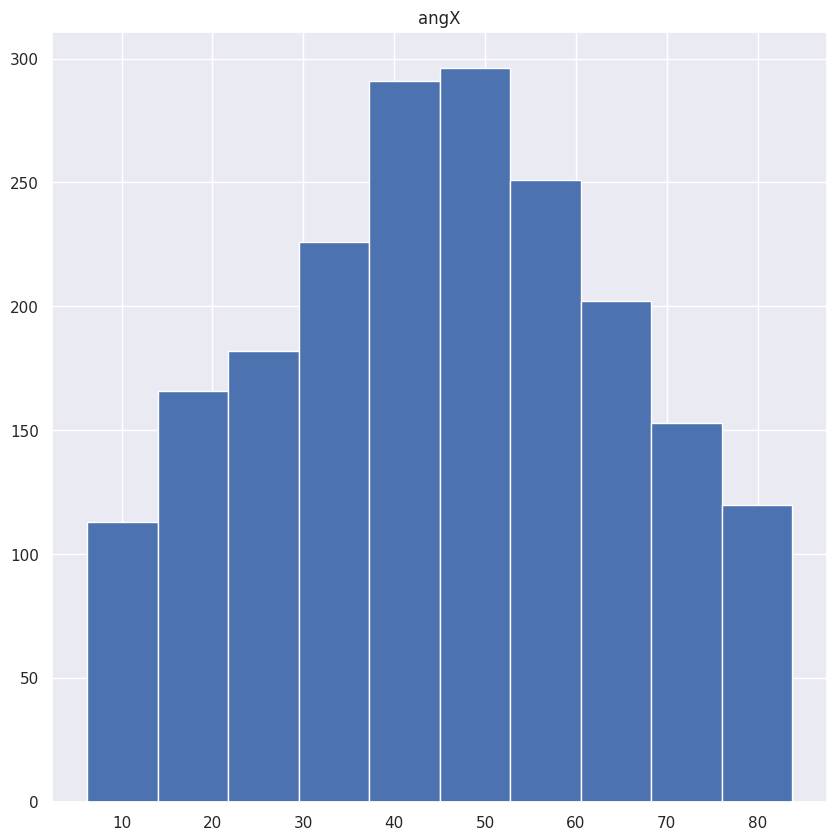

In [5]:
data.hist("angX")

array([[<Axes: title={'center': 'hypotenuse'}>]], dtype=object)

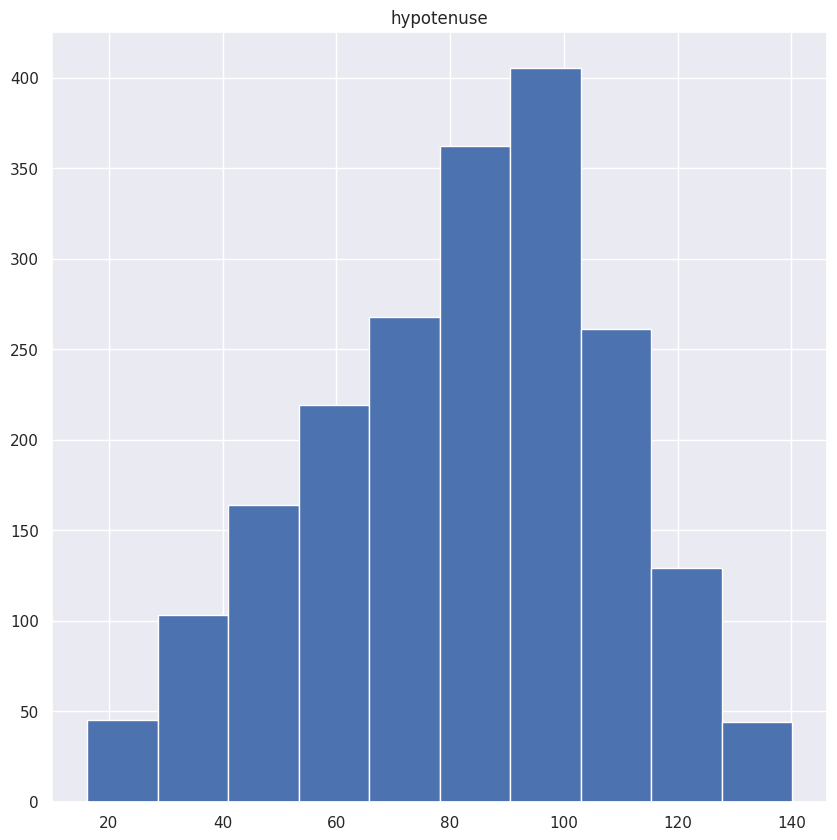

In [6]:
data.hist("hypotenuse")

array([[<Axes: title={'center': 'area'}>]], dtype=object)

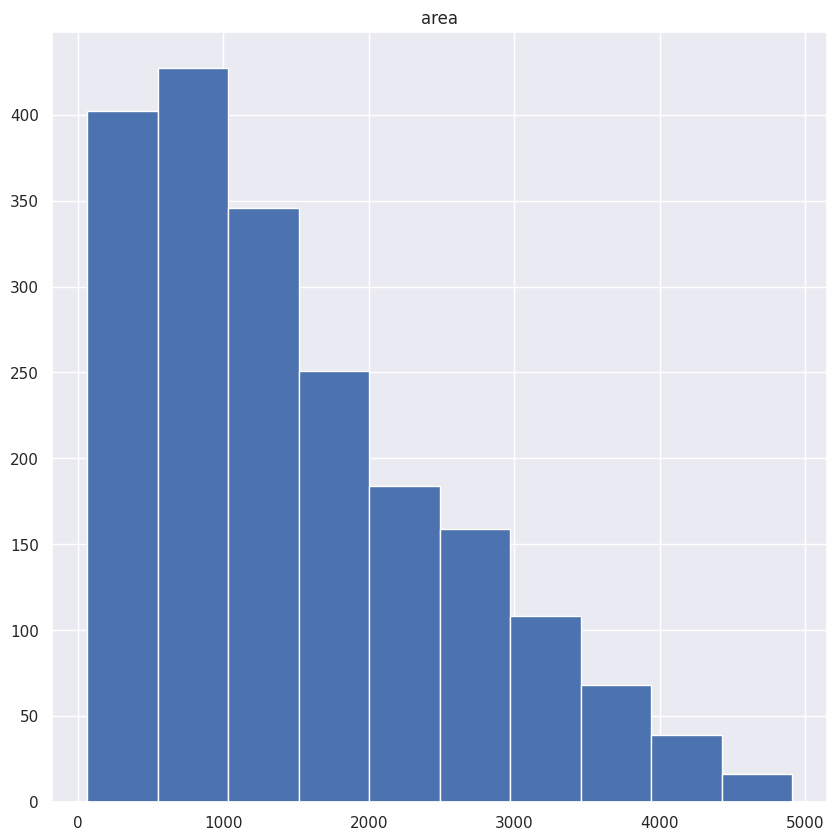

In [7]:
data.hist("area")

array([[<Axes: title={'center': 'perimeter'}>]], dtype=object)

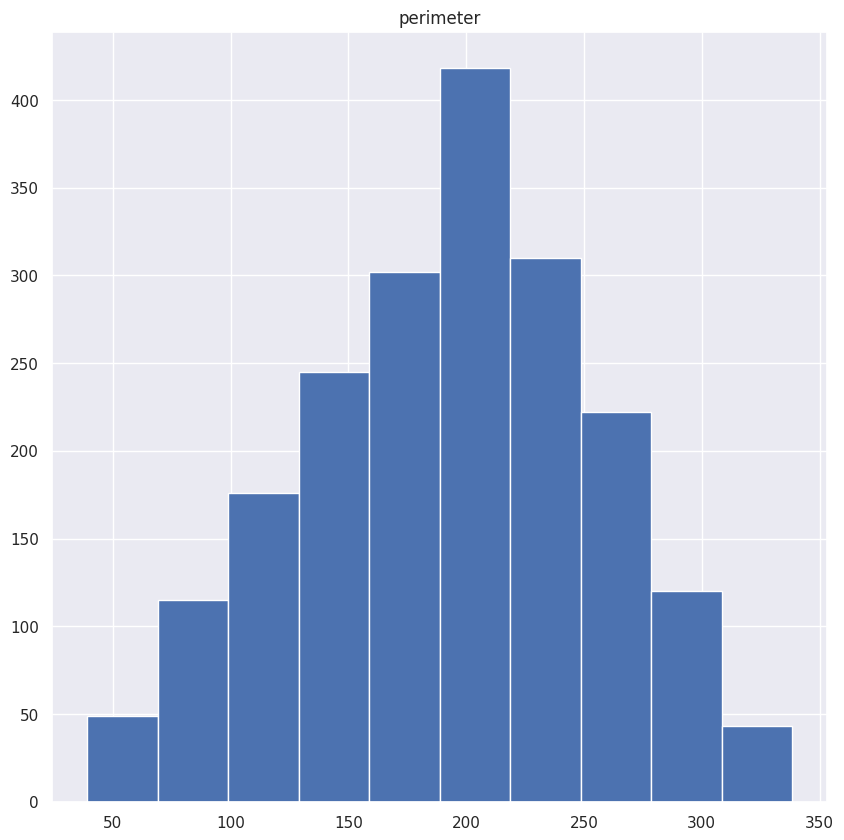

In [8]:
data.hist("perimeter")

<Axes: xlabel='origin_x', ylabel='origin_y'>

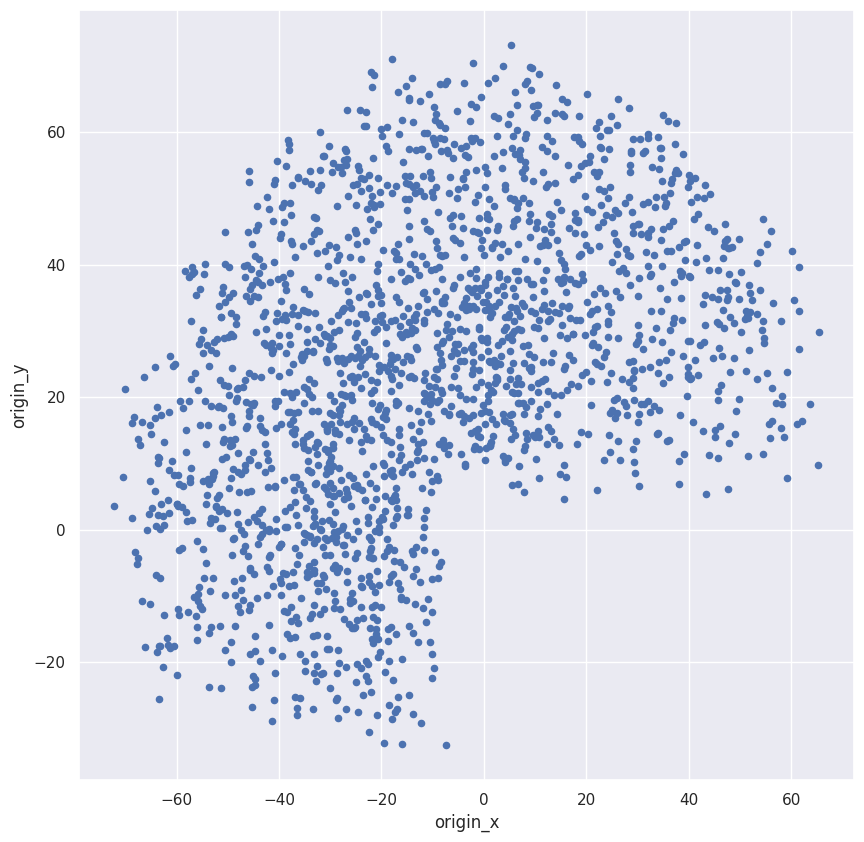

In [9]:
data.plot.scatter("origin_x", "origin_y")

In [10]:
sns.pairplot(data, hue ="hypotenuse")

Output hidden; open in https://colab.research.google.com to view.

Predicting Hypotenuse from lenX and lenY

Prepare data

In [11]:
# Select the (independant) features that we are going to use to train the model
X_lengths = data.loc[:, ["lenX", "lenY"]]
print(X_lengths)

        lenX    lenY
0    49.1196 85.0221
1    10.1378 51.1895
2    69.4121 99.4758
3    52.6354 75.8453
4    80.1719 21.8107
...      ...     ...
1995 62.0361 60.7049
1996 49.7388 64.6380
1997 91.5380 50.0104
1998 26.0840 31.3096
1999 38.6995 18.2888

[2000 rows x 2 columns]


In [12]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scalerX = StandardScaler()

# Apply the scaler to our X-features
X_lengths_scaled = scalerX.fit_transform(X_lengths)

In [13]:
#SAVE SCALER FOR LATER USE

import pickle
with open('Sscaler.pkl', 'wb') as f:
    pickle.dump(scalerX, f)

In [14]:
# Define the dependant variable / target to predict
y_reg = data.hypotenuse


In [15]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_lengths_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [16]:
print(X_train.shape)

(1600, 2)


Train model

In [17]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
SKmodel = LinearRegression()

# Model training
SKmodel.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(SKmodel.score(X_test, y_test))

0.9591510955626487


In [18]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, SKmodel.predict(X_test)))

25.018002716866548


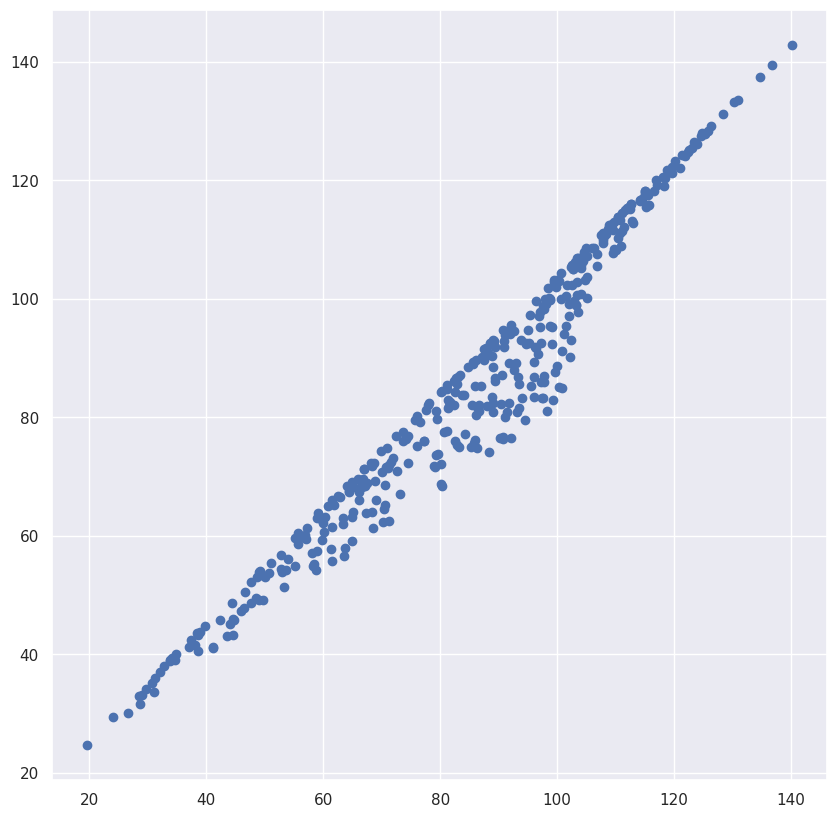

In [19]:
# We can also inspect our results visually
y_pred = SKmodel.predict(X_test)

plt.scatter(y_test,y_pred)

In [21]:
! pip install hvplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 5.6 MB/s eta 0:00:00


In [22]:
import hvplot.pandas # noqa: adds hvplot method to pandas objects

#print(data_test)
data_test["y_test"] = y_test
data_test["y_pred"] = y_pred

data_test.hvplot.scatter(x='y_test', y='y_pred', hover_cols=['lenX', 'lenY'], aspect=1) #or use index to hover


:Scatter   [y_test]   (y_pred,lenX,lenY)

In [23]:

#save sk learn model

with open('regModel.pkl', 'wb') as f:
    pickle.dump(SKmodel, f)

TENSORFLOW

In [29]:
# Instantiate a sequential model
TFmodel = tf.keras.models.Sequential()

TFmodel.add(tf.keras.layers.Dense(4, input_shape=(2,), activation='relu'))
TFmodel.add(tf.keras.layers.Dense(2, activation='relu'))

# Add a dense layer with 1 value output
TFmodel.add(tf.keras.layers.Dense(1, activation= "linear"))

# Compile your model
TFmodel.compile(optimizer = "adam", loss = "mean_squared_error")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
TFmodel.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Fit your model to the training data for 200 epochs
#we assign this to history variable so we can plot the training data
history = TFmodel.fit(X_train,y_train,epochs=200, validation_split=0.2)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7464.6626 - val_loss: 7519.8232
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7421.5845 - val_loss: 7482.5796
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7386.7085 - val_loss: 7452.8071
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7358.6914 - val_loss: 7429.3447
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7336.7773 - val_loss: 7410.1665
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7319.0171 - val_loss: 7395.1641
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7304.7109 - val_loss: 7382.5337
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7292.3428 - val_loss: 7371.4658
Epoch 9/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7281.3306 - val_loss: 7361.6357
Epoch 10/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7271.1406 - val_loss: 7352.8687
Epoch 11/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7261.9258 - val_loss: 7344.69

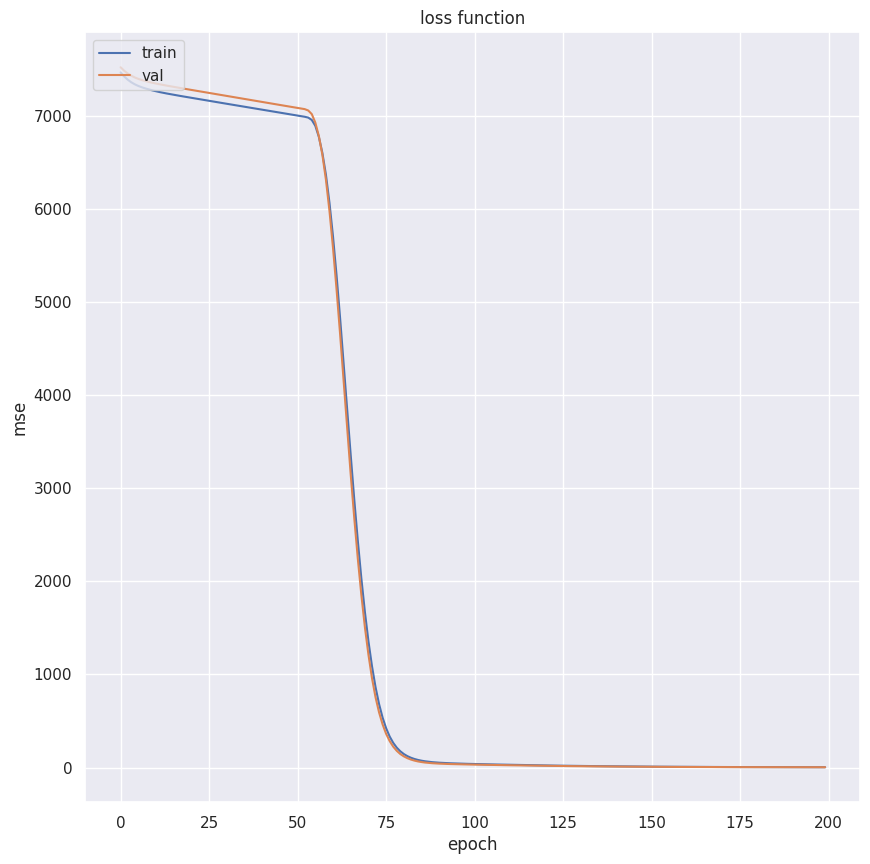

In [32]:
# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss function')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [33]:
# Evaluate your model accuracy on the test data
loss_test = TFmodel.evaluate(X_test,y_test)

# Print accuracy
print('mse_test:', loss_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7785  
mse_test: 2.7784597873687744


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


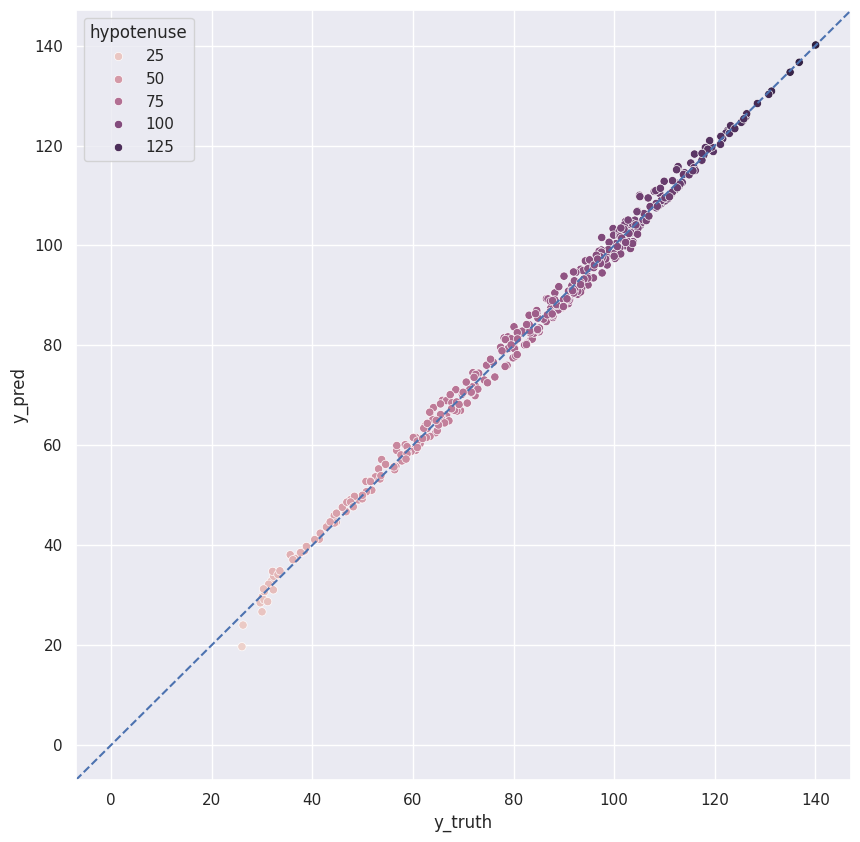

In [35]:
# We can also inspect our results visually
y_pred = TFmodel.predict(X_test)

data_test["y_predANN"] = y_pred
data_test["truth"] = y_test
sns.scatterplot(x = "y_predANN", y = "truth", data = data_test, hue = "hypotenuse")
plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [36]:
#save tf model
TFmodel.save('tfModel.keras')

In [37]:

TFmodel.save('tfModel.h5')

In [38]:
import keras
model = keras.models.load_model('tfModel.keras')

print(model)
model.summary()

<Sequential name=sequential_1, built=True>


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77 (312.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52 (212.00 B)